<a href="https://colab.research.google.com/github/varshudinu0408/Varshini-R/blob/main/loan_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = {
    "Gender": ["Male", "Male", "Female", "Female", "Male"],
    "Married": ["Yes", "No", "Yes", "No", "Yes"],
    "ApplicantIncome": [5000, 3000, 4500, 2500, 6000],
    "LoanAmount": [150, 100, 120, 80, 180],
    "Credit_History": [1, 1, 0, 1, 1],
    "Loan_Status": ["Y", "N", "Y", "N", "Y"]
}

df = pd.DataFrame(data)

print(df)

   Gender Married  ApplicantIncome  LoanAmount  Credit_History Loan_Status
0    Male     Yes             5000         150               1           Y
1    Male      No             3000         100               1           N
2  Female     Yes             4500         120               0           Y
3  Female      No             2500          80               1           N
4    Male     Yes             6000         180               1           Y


## Data Visualization

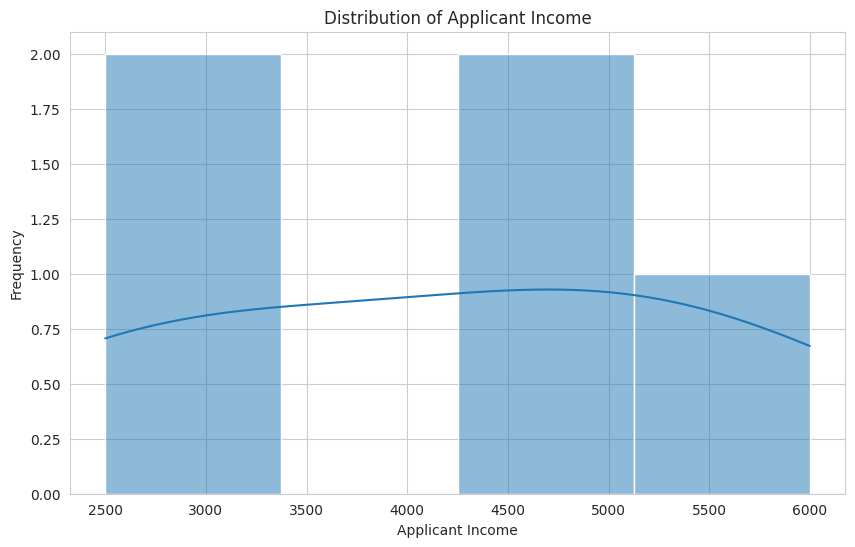

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Histogram for ApplicantIncome
plt.figure(figsize=(10, 6))
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1475/1712859486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='viridis')


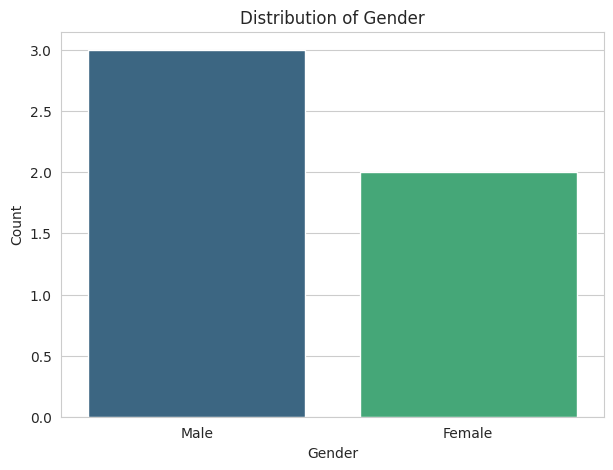

In [ ]:
# Bar plot for Gender distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1475/205380539.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='plasma')


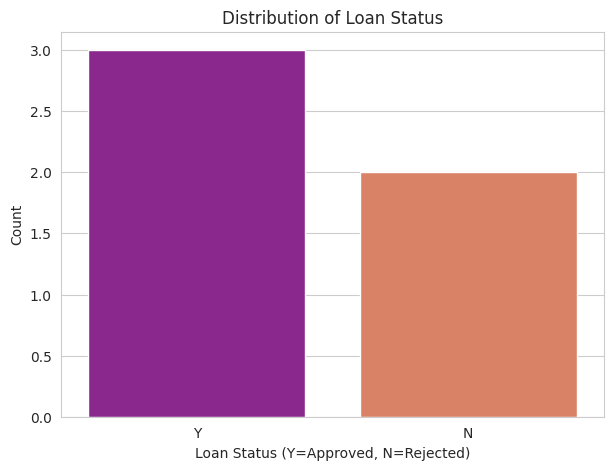

In [ ]:
# Bar plot for Loan_Status distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Loan_Status', data=df, palette='plasma')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Count')
plt.show()

## Analyzing Loan Approval Criteria

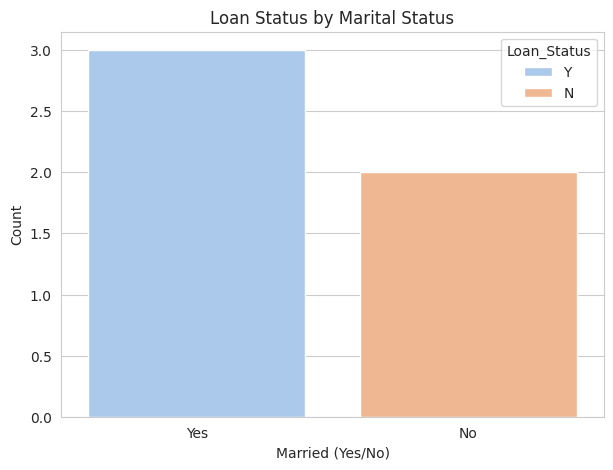

In [ ]:
# Relationship between Married status and Loan_Status
plt.figure(figsize=(7, 5))
sns.countplot(x='Married', hue='Loan_Status', data=df, palette='pastel')
plt.title('Loan Status by Marital Status')
plt.xlabel('Married (Yes/No)')
plt.ylabel('Count')
plt.show()

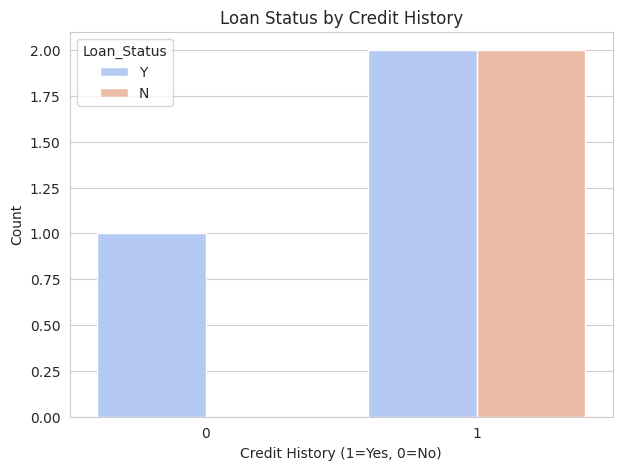

In [ ]:
# Relationship between Credit_History and Loan_Status
plt.figure(figsize=(7, 5))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='coolwarm')
plt.title('Loan Status by Credit History')
plt.xlabel('Credit History (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1475/3752670812.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, palette='muted')


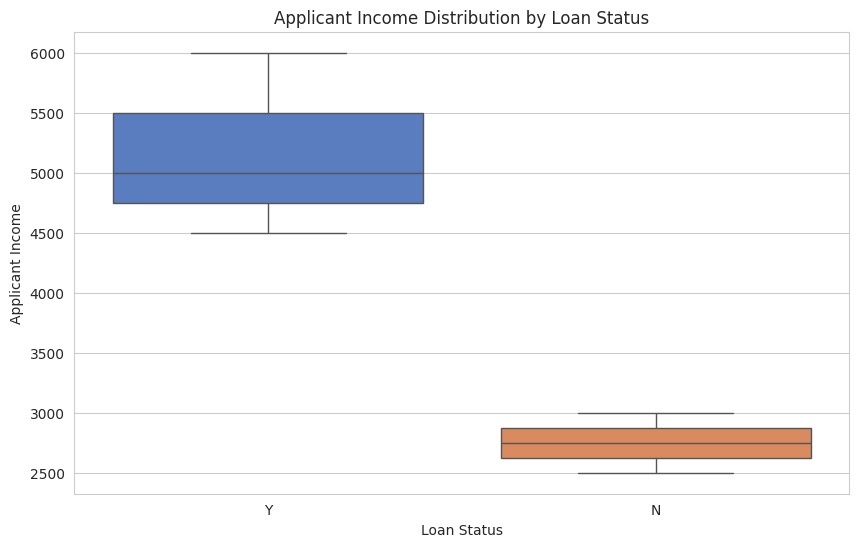

In [ ]:
# Relationship between ApplicantIncome and Loan_Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, palette='muted')
plt.title('Applicant Income Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()

   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000           80

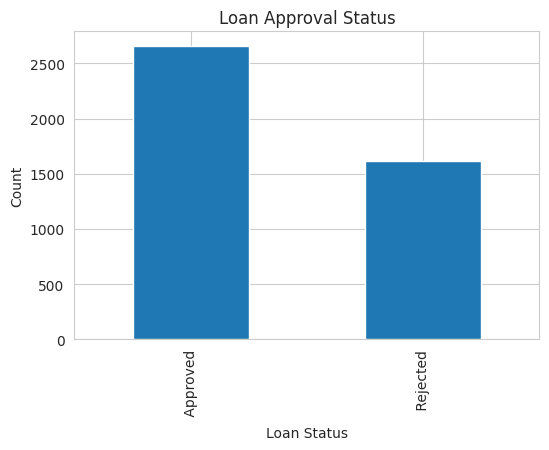

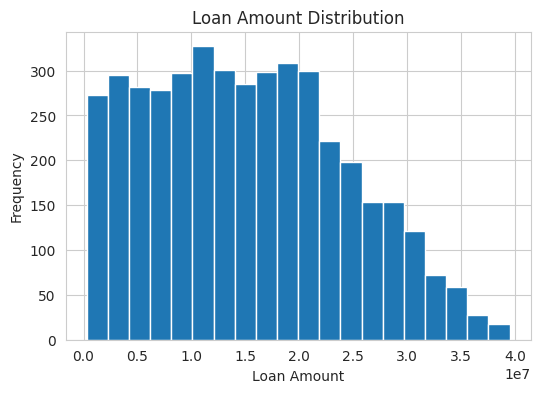

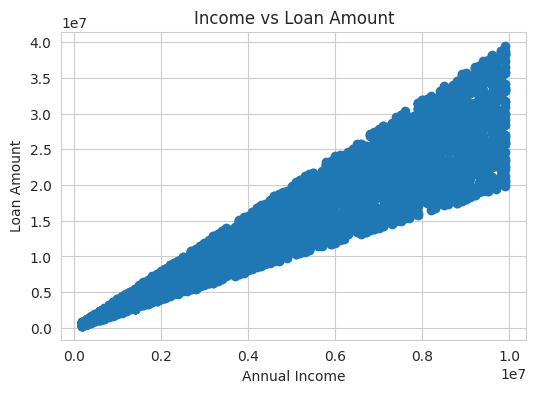

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("loan_approval_dataset.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.head())

# 1. Loan Approval Count
plt.figure(figsize=(6,4))
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# 2. Loan Amount Distribution
plt.figure(figsize=(6,4))
plt.hist(df['loan_amount'], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

# 3. Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df['income_annum'], df['loan_amount'])
plt.title("Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("loan_approval_dataset.csv")

# Remove spaces in column names
df.columns = df.columns.str.strip()

# Convert categorical columns to numbers
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

# Features and Target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 97.42388758782201
